In [ ]:
import sys
import os
import importlib
sys.path.insert(0, os.path.abspath('..'))

import random
from PIL import Image, ImageFilter, ImageDraw
import matplotlib.pyplot as plt
import Augmente.ScannerFocusLoss as scanner_focus_loss_module

importlib.reload(scanner_focus_loss_module)
RandomScannerFocusLoss = scanner_focus_loss_module.RandomScannerFocusLoss

In [2]:
sample_img_path = os.path.join('..', 'dataset_split', 'test', 'image')
image_files = [f for f in os.listdir(sample_img_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
sample_img = Image.open(os.path.join(sample_img_path, image_files[0])).convert('RGB')

In [3]:
focus_loss_transofrm = RandomScannerFocusLoss(
    p=1.0,
    blur_radius_range=(4.0, 8.0),
    global_blur_p=0.15,
    min_mask_coverage=0.18,
    feather_range=(1.0, 3.0),
    blur_strength_multiplier=1.8,
)

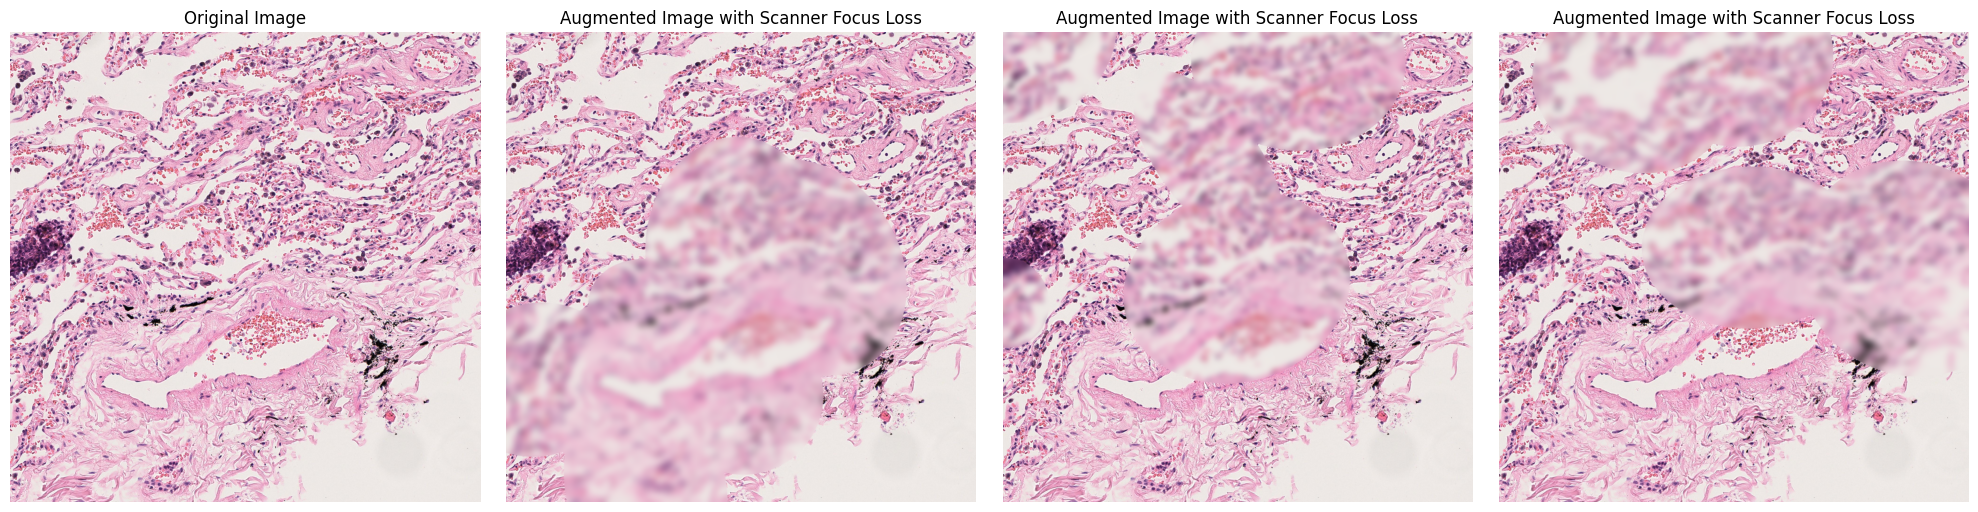

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(sample_img)
axes[0].set_title('Original Image')
axes[0].axis('off')

for i in range(1, 4):
    augmented_img = focus_loss_transofrm(sample_img)
    axes[i].imshow(augmented_img)
    axes[i].set_title('Augmented Image with Scanner Focus Loss')
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()